In [2]:
import numpy as np
import sys
import itertools
import sparse

from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
import matplotlib.cm as cm


def set_size2(width, fraction=1,heightmod=1):
    """Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width: float
            Document textwidth or columnwidth in pts
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy

    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width * fraction

    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio * heightmod

    fig_dim = (fig_width_in, fig_height_in)

    return fig_dim


params = {
    "text.usetex": True,
    "font.family": "serif",
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 10,
    "font.size": 10,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
          }
plt.rcParams.update(params)

In [10]:
NL=200
L=6
ts=np.linspace(0,5,51)
Sizes6=np.linspace(0,L,L+1)
Nsamp=100
WorkingDir='SpinModelL6v2/'

Lanczos6=np.zeros((NL-1),dtype=complex)
for j in range(100):
    Lanczos6+=np.loadtxt(WorkingDir+'LanczosCoefficients_sample'+str(j)+'.txt',delimiter=',',dtype=complex)
Lanczos6/=Nsamp
Lanczos6=np.real(Lanczos6)


Phi6=np.zeros((len(ts),NL),dtype=complex)
for j in range(100):
    Phi6+=np.loadtxt(WorkingDir+'Phi_sample'+str(j)+'.txt',delimiter=',',dtype=complex)
Phi6/=Nsamp

SizeOverlaps6=np.zeros((L+1,L+1),dtype=complex)
for j in range(100):
    SizeOverlaps6+=np.loadtxt(WorkingDir+'Sizeoverlaps_sample'+str(j)+'.txt',delimiter=',',dtype=complex)
SizeOverlaps6/=Nsamp

WindingDistributions6=np.zeros((L+1, len(ts)), dtype=complex)
for j in range(100):
    WindingDistributions6+=np.loadtxt(WorkingDir+'WindingDistributions_sample'+str(j)+'.txt',delimiter=',',dtype=complex)
WindingDistributions6/=Nsamp



def PhiFT6(tind,mu):
    nvec=np.array([np.exp(1j*n*mu) for n in range(NL)])
    datFT=Phi6[tind,:]
    return abs(nvec@(datFT**2))


def SizeFT6(tind,mu):
    nvec=np.array([np.exp(1j*n*mu) for n in range(L+1)])
    datFT=WindingDistributions6[:,tind]
    return abs(nvec@datFT)


def SizeFTD6(tind,mu):
    nvec=np.array([np.exp(1j*n*mu) for n in range(L+1)])
    datFT=diagonalwinding6[tind,:]
    return abs(nvec@datFT)


xdat=np.linspace(-np.pi,np.pi,3000)

xdatS=np.linspace(-1,0,1000)
xdatK=np.linspace(-np.pi,0,1000)



CK6=(2**L)*np.array([[abs(PhiFT6(t,mu)) for mu in xdat] for t in range(len(ts))])
CS6=np.array([[abs(SizeFT6(t,mu)) for mu in xdat] for t in range(len(ts))])
diagonalwinding6=(Phi6[:,:L+1]**2)@SizeOverlaps6
CSD6=(2**L)*np.array([[abs(SizeFTD6(t,mu)) for mu in xdat] for t in range(len(ts))])


muS6=[]
muK6=[]
muSD6=[]

for tind in range(len(ts)):
    max=np.max(CK6[tind])
    ind=np.where(CK6[tind]==max)[0][0]
    muK6.append(xdat[ind])

    max=np.max(CS6[tind])
    ind=np.where(CS6[tind]==max)[0][0]
    muS6.append(xdat[ind])

    max=np.max(CSD6[tind])
    ind=np.where(CSD6[tind]==max)[0][0]
    muSD6.append(xdat[ind])





muS6=np.array(muS6)
muK6=np.array(muK6)
muSD6=np.array(muSD6)

In [12]:
NL=200
L=6
ts=np.linspace(0,5,51)
Sizes6=np.linspace(0,L,L+1)
Nsamp=100
WorkingDir='SpinModelL6v2/'

Lanczos6=np.zeros((NL-1),dtype=complex)
for j in range(100):
    Lanczos6+=np.loadtxt(WorkingDir+'LanczosCoefficients_sample'+str(j)+'.txt',delimiter=',',dtype=complex)
Lanczos6/=Nsamp
Lanczos6=np.real(Lanczos6)


Phi6=np.zeros((len(ts),NL),dtype=complex)
for j in range(100):
    Phi6+=np.loadtxt(WorkingDir+'Phi_sample'+str(j)+'.txt',delimiter=',',dtype=complex)
Phi6/=Nsamp

SizeOverlaps6=np.zeros((L+1,L+1),dtype=complex)
for j in range(100):
    SizeOverlaps6+=np.loadtxt(WorkingDir+'Sizeoverlaps_sample'+str(j)+'.txt',delimiter=',',dtype=complex)
SizeOverlaps6/=Nsamp

WindingDistributions6=np.zeros((L+1, len(ts)), dtype=complex)
for j in range(100):
    WindingDistributions6+=np.loadtxt(WorkingDir+'WindingDistributions_sample'+str(j)+'.txt',delimiter=',',dtype=complex)
WindingDistributions6/=Nsamp



def PhiFT6(tind,mu):
    nvec=np.array([np.exp(1j*n*mu) for n in range(NL)])
    datFT=Phi6[tind,:]
    return abs(nvec@(datFT**2))


def SizeFT6(tind,mu):
    nvec=np.array([np.exp(1j*n*mu) for n in range(L+1)])
    datFT=WindingDistributions6[:,tind]
    return abs(nvec@datFT)


def SizeFTD6(tind,mu):
    nvec=np.array([np.exp(1j*n*mu) for n in range(L+1)])
    datFT=diagonalwinding6[tind,:]
    return abs(nvec@datFT)


xdat=np.linspace(-np.pi,np.pi,3000)

xdatS=np.linspace(-1,0,1000)
xdatK=np.linspace(-np.pi,0,1000)



CK6=(2**L)*np.array([[abs(PhiFT6(t,mu)) for mu in xdat] for t in range(len(ts))])
CS6=np.array([[abs(SizeFT6(t,mu)) for mu in xdat] for t in range(len(ts))])
diagonalwinding6=(Phi6[:,:L+1]**2)@SizeOverlaps6
CSD6=(2**L)*np.array([[abs(SizeFTD6(t,mu)) for mu in xdat] for t in range(len(ts))])


muS6=[]
muK6=[]
muSD6=[]

for tind in range(len(ts)):
    max=np.max(CK6[tind])
    ind=np.where(CK6[tind]==max)[0][0]
    muK6.append(xdat[ind])

    max=np.max(CS6[tind])
    ind=np.where(CS6[tind]==max)[0][0]
    muS6.append(xdat[ind])

    max=np.max(CSD6[tind])
    ind=np.where(CSD6[tind]==max)[0][0]
    muSD6.append(xdat[ind])



muS6=np.array(muS6)
muK6=np.array(muK6)
muSD6=np.array(muSD6)

In [13]:
NL=200
L=8
ts=np.linspace(0,5,51)
Sizes8=np.linspace(0,L,L+1)
Nsamp=100
WorkingDir='SpinModelL8v2/'

Lanczos8=np.zeros((NL-1),dtype=complex)
for j in range(100):
    Lanczos8+=np.loadtxt(WorkingDir+'LanczosCoefficients_sample'+str(j)+'.txt',delimiter=',',dtype=complex)
Lanczos8/=Nsamp
Lanczos8=np.real(Lanczos8)


Phi8=np.zeros((len(ts),NL),dtype=complex)
for j in range(100):
    Phi8+=np.loadtxt(WorkingDir+'Phi_sample'+str(j)+'.txt',delimiter=',',dtype=complex)
Phi8/=Nsamp

SizeOverlaps8=np.zeros((L+1,L+1),dtype=complex)
for j in range(100):
    SizeOverlaps8+=np.loadtxt(WorkingDir+'Sizeoverlaps_sample'+str(j)+'.txt',delimiter=',',dtype=complex)
SizeOverlaps8/=Nsamp

WindingDistributions8=np.zeros((L+1, len(ts)), dtype=complex)
for j in range(100):
    WindingDistributions8+=np.loadtxt(WorkingDir+'WindingDistributions_sample'+str(j)+'.txt',delimiter=',',dtype=complex)
WindingDistributions8/=Nsamp



def PhiFT8(tind,mu):
    nvec=np.array([np.exp(1j*n*mu) for n in range(NL)])
    datFT=Phi8[tind,:]
    return abs(nvec@(datFT**2))


def SizeFT8(tind,mu):
    nvec=np.array([np.exp(1j*n*mu) for n in range(L+1)])
    datFT=WindingDistributions8[:,tind]
    return abs(nvec@datFT)


def SizeFTD8(tind,mu):
    nvec=np.array([np.exp(1j*n*mu) for n in range(L+1)])
    datFT=diagonalwinding8[tind,:]
    return abs(nvec@datFT)



xdat=np.linspace(-np.pi,np.pi,3000)


xdatS=np.linspace(-np.pi,0,1000)
xdatK=np.linspace(-np.pi,0,1000)

CK8=(2**L)*np.array([[abs(PhiFT8(t,mu)) for mu in xdat] for t in range(len(ts))])
CS8=np.array([[abs(SizeFT8(t,mu)) for mu in xdat] for t in range(len(ts))])
diagonalwinding8=(Phi8[:,:L+1]**2)@SizeOverlaps8
CSD8=(2**L)*np.array([[abs(SizeFTD8(t,mu)) for mu in xdat] for t in range(len(ts))])


muS8=[]
muK8=[]
muSD8=[]

for tind in range(len(ts)):
    max=np.max(CK8[tind])
    ind=np.where(CK8[tind]==max)[0][0]
    muK8.append(xdat[ind])

    max=np.max(CS8[tind])
    ind=np.where(CS8[tind]==max)[0][0]
    muS8.append(xdat[ind])

    max=np.max(CSD8[tind])
    ind=np.where(CSD8[tind]==max)[0][0]
    muSD8.append(xdat[ind])


muS8=np.array(muS8)
muK8=np.array(muK8)
muSD8=np.array(muSD8)

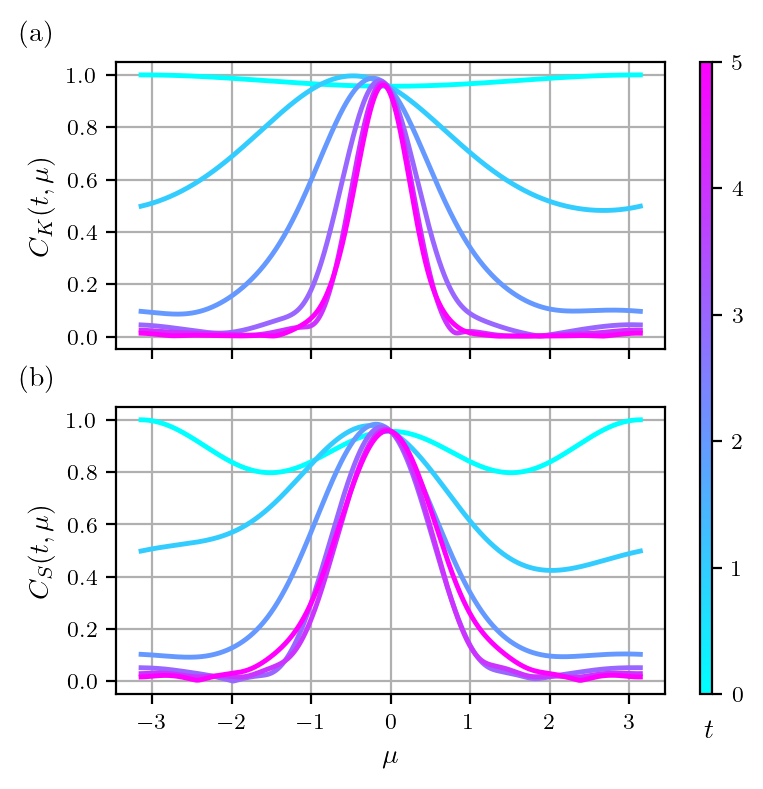

In [14]:
import matplotlib.gridspec as gridspec
width=426.79135
fig, ax = plt.subplots(2,1,dpi=200,figsize=set_size2(width,0.75,1.5),sharex=True)

times=ts
tinds=[0,10,20,30,40,50]
colors=plt.cm.cool(np.linspace(0,1,len(tinds)))

coloriter=0
for tind in tinds:
    ax[0].plot(xdat,CK8[tind],label=r'$t=$'+str(times[tind]),color=colors[coloriter],lw=1.75)
    ax[1].plot(xdat,CS8[tind],label=r'$t=$'+str(times[tind]),color=colors[coloriter],lw=1.75)
    coloriter+=1



ax[0].set_ylabel(r'$C_{K}(t,\mu)$')
ax[0].grid(True)
ax[0].set_axisbelow(True)
ax[0].text(-0.175,1.075,r'(a)', transform=ax[0].transAxes)


ax[1].set_xlabel(r'$\mu$')
ax[1].set_ylabel(r'$C_{S}(t,\mu)$')
ax[1].grid(True)
ax[1].set_axisbelow(True)
ax[1].text(-0.175,1.075,r'(b)', transform=ax[1].transAxes)
ax[1].text(1.07,-0.15,r'$t$', transform=ax[1].transAxes)


normalize = mcolors.Normalize(vmin=ts[tinds[0]], vmax=ts[tinds[-1]])
colormap = cm.cool
scalarmappable = cm.ScalarMappable(norm=normalize, cmap=colormap)
plt.colorbar(scalarmappable, ax=ax[0:2], location='right',aspect=50)
plt.show()